# 01. Исследование данных (EDA) — рекомендации банковских продуктов

EDA для построения модели, которая по данным о клиенте за текущий месяц будет предлагать ему **новые** банковские продукты на следующий месяц.

Изучаются данные:
1. какие поля есть и насколько они заполнены;
2. сколько месяцев и клиентов в файле;
3. какие продукты встречаются часто, а какие редко;
4. как часто клиент реально открывает **новый** продукт (продукта не было раньше, а в следующем месяце продукт появился у клиента);
5. как лучше разделить данные на обучение и проверку **по времени** без заглядывания в будущее.

**Проблема - dataset большой, компьютер зависает**

Файл `train_ver2.csv` - содержит миллионы строк. Если загрузить его целиком, компьютер зависает из за нехватки памяти. Локально тестировать полный датасет не возможно.

Поэтому:
- сначала смотрим на небольшую выборку строк;
- полные подсчёты делаем, читая файл **порциями** (по несколько сотен тысяч строк за раз);
- важные промежуточные таблицы сохраняем на диск в папку `data/processed/eda/`;
- для тяжёлых сравнений месяцев заранее сохраняем «облегчённые» помесячные файлы;
- графики строим по уже посчитанным итогам или по ограниченной выборке.

> Перед запуском положите исходный файл сюда: `data/raw/train_ver2.csv` (см. `data/README.md`).  
> Ячейки нужно запускать **по порядку**. Если памяти мало — уменьшите `CHUNKSIZE` в первой кодовой ячейке (например, до `100_000` или `200_000`).


## 1. Подготовка: библиотеки, пути и константы

**Что делаем**

Подключаем нужные библиотеки, задаём пути к данным, размер порции чтения и списки важных столбцов. Эти настройки используются во всех следующих шагах, чтобы не дублировать их вручную.


In [1]:
from __future__ import annotations

import json
import gc
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import display

# Фиксируем случайность: выборки и графики будут воспроизводимы при повторном запуске
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

# Корень проекта: ноутбук лежит в notebooks/, поэтому поднимаемся на уровень выше
ROOT = Path("..").resolve()
RAW_PATH = ROOT / "data" / "raw" / "train_ver2.csv"
EDA_DIR = ROOT / "data" / "processed" / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

# Сюда сохраним облегчённые помесячные таблицы (только id и продукты)
SLIM_DIR = EDA_DIR / "months_slim"

# Границы разделения данных по времени берём из общего конфига проекта
CONFIG_PATH = ROOT / "configs" / "train.yaml"
with CONFIG_PATH.open(encoding="utf-8") as f:
    CONFIG = yaml.safe_load(f)

# Сколько строк читать за один раз из большого CSV.
# Чем меньше число — тем меньше нагрузка на память, но дольше чтение.
CHUNKSIZE = 400_000

# Сколько строк достаточно для быстрых графиков и первичного осмотра
SAMPLE_ROWS = 150_000

ID_COL = "ncodpers"      # идентификатор клиента
DATE_COL = "fecha_dato"  # дата месячного среза

# 24 банковских продукта: 1 = продукт есть у клиента в этом месяце, 0 = нет
PRODUCT_COLS = [
    "ind_ahor_fin_ult1",
    "ind_aval_fin_ult1",
    "ind_cco_fin_ult1",
    "ind_cder_fin_ult1",
    "ind_cno_fin_ult1",
    "ind_ctju_fin_ult1",
    "ind_ctma_fin_ult1",
    "ind_ctop_fin_ult1",
    "ind_ctpp_fin_ult1",
    "ind_deco_fin_ult1",
    "ind_deme_fin_ult1",
    "ind_dela_fin_ult1",
    "ind_ecue_fin_ult1",
    "ind_fond_fin_ult1",
    "ind_hip_fin_ult1",
    "ind_plan_fin_ult1",
    "ind_pres_fin_ult1",
    "ind_reca_fin_ult1",
    "ind_tjcr_fin_ult1",
    "ind_valo_fin_ult1",
    "ind_viv_fin_ult1",
    "ind_nomina_ult1",
    "ind_nom_pens_ult1",
    "ind_recibo_ult1",
]

# Поля анкеты / профиля клиента (возраст, доход, сегмент и т.п.)
PROFILE_COLS = [
    "ind_empleado",
    "pais_residencia",
    "sexo",
    "age",
    "fecha_alta",
    "ind_nuevo",
    "antiguedad",
    "indrel",
    "ult_fec_cli_1t",
    "indrel_1mes",
    "tiprel_1mes",
    "indresi",
    "indext",
    "conyuemp",
    "canal_entrada",
    "indfall",
    "tipodom",
    "cod_prov",
    "nomprov",
    "ind_actividad_cliente",
    "renta",
    "segmento",
]


def to_numeric_clean(series: pd.Series) -> pd.Series:
    """Превращает "текстовые числа" в настоящие числа.

    В исходном файле age / antiguedad / renta часто записаны как текст
    с пробелами или пометками вроде NA. Такие значения нельзя сразу
    использовать в расчётах и графиках.
    """
    s = series.astype("string").str.strip()
    s = s.replace({"": pd.NA, "NA": pd.NA, "na": pd.NA, "None": pd.NA})
    # errors="coerce": то, что не удалось разобрать, станет пропуском
    return pd.to_numeric(s, errors="coerce")


print("Исходный файл найден:", RAW_PATH.exists(), "→", RAW_PATH)
print("Папка для промежуточных результатов:", EDA_DIR)
print("Границы разделения из конфига:", CONFIG.get("split"))
print("Сколько рекомендаций отдаём по умолчанию (top_k):", CONFIG.get("model", {}).get("top_k"))


Исходный файл найден: True → C:\work\yandex\source\mle-pr-final\data\raw\train_ver2.csv
Папка для промежуточных результатов: C:\work\yandex\source\mle-pr-final\data\processed\eda
Границы разделения из конфига: {'train_end': '2015-12-28', 'valid_end': '2016-04-28'}
Сколько рекомендаций отдаём по умолчанию (top_k): 7


## 2. Смотрим структуру файла на небольшой выборке

**Что проверяем**

Не читаем весь файл. Берём только первые `SAMPLE_ROWS` строк и отвечаем на вопросы:
- какие столбцы есть;
- какого они типа (число / текст);
- сколько разных значений встречается в выборке;
- где уже на выборке много пустых ячеек.

**Зачем это нужно**

Так мы быстро понимаем «каркас» таблицы и какие поля потом потребуют очистки, не тратя память на весь датасет.


In [2]:
assert RAW_PATH.exists(), (
    f"Нет файла {RAW_PATH}. Скачайте датасет и положите train_ver2.csv (см. data/README.md)."
)

# low_memory=False: на ограниченной выборке типы столбцов определяются стабильнее
sample = pd.read_csv(RAW_PATH, nrows=SAMPLE_ROWS, low_memory=False)
header_cols = sample.columns.tolist()

# Краткая «карточка» каждого столбца по выборке
schema = pd.DataFrame(
    {
        "column": sample.columns,
        "dtype": sample.dtypes.astype(str).values,
        "n_unique_sample": [sample[c].nunique(dropna=True) for c in sample.columns],
        "na_rate_sample": sample.isna().mean().values,  # доля пустых ячеек
    }
)
schema_path = EDA_DIR / "01_schema_sample.parquet"
schema.to_parquet(schema_path, index=False)

print("Размер выборки (строки, столбцы):", sample.shape)
print("Число столбцов:", sample.shape[1])
print("Сохранено:", schema_path)
display(schema.head(30))
# Столбцы с наибольшей долей пропусков — кандидаты на особую обработку или отказ от использования
display(schema.sort_values("na_rate_sample", ascending=False).head(15))

# Ожидаемые наблюдения:
# 1) Есть id клиента, дата месяца, анкета и около 24 флагов продуктов.
# 2) Возраст и стаж часто приходят текстом — их нужно аккуратно перевести в числа.
# 3) Некоторые поля почти всегда пустые — для модели они малополезны.


Размер выборки (строки, столбцы): (150000, 48)
Число столбцов: 48
Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\01_schema_sample.parquet


,column,dtype,n_unique_sample,na_rate_sample
0,fecha_dato,object,1,0.000000
1,ncodpers,int64,150000,0.000000
2,ind_empleado,object,2,0.007313
3,pais_residencia,object,51,0.007313
4,sexo,object,2,0.007313
5,age,object,101,0.000000
6,fecha_alta,object,1303,0.007313
7,ind_nuevo,float64,2,0.007313
8,antiguedad,object,66,0.000000
9,indrel,float64,2,0.007313


,column,dtype,n_unique_sample,na_rate_sample
15,conyuemp,float64,0,1.000000
10,ult_fec_cli_1t,object,22,0.998693
22,renta,float64,112378,0.179487
20,nomprov,object,52,0.009413
19,cod_prov,float64,52,0.009413
23,segmento,object,3,0.007380
16,canal_entrada,object,50,0.007353
17,indfall,object,2,0.007313
12,tiprel_1mes,object,3,0.007313
21,ind_actividad_cliente,float64,2,0.007313


## 3. Делаем компактные типы столбцов

Pandas часто выбирает слишком широкие типы и зря расходует память. Заранее узкие типы помогают пройти весь файл порциями безопаснее.

По списку столбцов составляем словарь: какой столбец каким типом читать дальше.

Например:
- флаги продуктов храним как маленькие целые числа `0/1` (с поддержкой пустых значений);
- идентификатор клиента — как целое число;
- текстовые категории и «грязные» числа сначала читаем как текст.


In [3]:
def build_dtype_map(columns: list[str]) -> dict[str, str]:
    """Возвращает словарь «имя столбца → тип при чтении».

    Даты специально читаем как текст и при необходимости разбираем позже —
    так меньше сюрпризов из-за разного формата записи.
    """
    dtypes: dict[str, str] = {}
    for col in columns:
        if col in PRODUCT_COLS:
            dtypes[col] = "Int8"  # 0/1, плюс допускается пустое значение
        elif col == ID_COL:
            dtypes[col] = "int32"
        elif col in {"cod_prov", "tipodom", "ind_nuevo", "indrel", "ind_actividad_cliente"}:
            # Float32 удобен, когда в числовом поле бывают пропуски
            dtypes[col] = "Float32"
        elif col in {"age", "antiguedad", "renta"}:
            # В сырье часто текст; сначала читаем строкой, чистим функцией to_numeric_clean
            dtypes[col] = "string"
        elif col in {
            DATE_COL,
            "fecha_alta",
            "ult_fec_cli_1t",
            "ind_empleado",
            "pais_residencia",
            "sexo",
            "indrel_1mes",
            "tiprel_1mes",
            "indresi",
            "indext",
            "conyuemp",
            "canal_entrada",
            "indfall",
            "nomprov",
            "segmento",
        }:
            dtypes[col] = "string"
    return dtypes


DTYPE_MAP = build_dtype_map(header_cols)
dtype_path = EDA_DIR / "02_dtype_map.json"
dtype_path.write_text(json.dumps(DTYPE_MAP, ensure_ascii=False, indent=2), encoding="utf-8")
print("Сколько столбцов в карте типов:", len(DTYPE_MAP), "→", dtype_path)

# Выборка для схемы больше не нужна — освобождаем память перед полным проходом
del sample
gc.collect()

# Итог шага: карта типов сохранена и будет использована при чтении всего файла порциями.


Сколько столбцов в карте типов: 48 → C:\work\yandex\source\mle-pr-final\data\processed\eda\02_dtype_map.json


33

## 4. Полный проход по файлу порциями: объём, месяцы, пропуски, владение продуктами

Для оптимизации работы с памятью, один раз проходим весь CSV небольшими кусками и накапливаем только итоговые счётчики:
- сколько всего строк;
- сколько строк приходится на каждый месяц (`fecha_dato`);
- сколько пустых значений в каждом столбце;
- как часто клиенты уже владеют каждым продуктом.

В оперативной памяти держим только текущий кусок и небольшие словари с итогами. Сами куски на диск не сохраняем — сохраняем уже готовые сводные таблицы.


In [4]:
# Берём только нужные столбцы: так каждый кусок занимает меньше памяти
usecols = [c for c in [ID_COL, DATE_COL] + PROFILE_COLS + PRODUCT_COLS if c in header_cols]
missing_products = [c for c in PRODUCT_COLS if c not in header_cols]
if missing_products:
    print("Внимание: в файле нет колонок продуктов:", missing_products)

n_rows = 0
month_counts: dict[str, int] = {}
na_counts = {c: 0 for c in usecols}
product_owned_sum = {c: 0 for c in PRODUCT_COLS if c in usecols}
product_non_null = {c: 0 for c in PRODUCT_COLS if c in usecols}

reader = pd.read_csv(
    RAW_PATH,
    usecols=usecols,
    dtype={k: v for k, v in DTYPE_MAP.items() if k in usecols},
    chunksize=CHUNKSIZE,
    low_memory=False,
)

for i, chunk in enumerate(reader):
    n_rows += len(chunk)

    # Дата среза: оставляем только YYYY-MM-DD (на случай лишнего времени в строке)
    dates = chunk[DATE_COL].astype("string").str.slice(0, 10)
    vc = dates.value_counts()
    for d, cnt in vc.items():
        month_counts[d] = month_counts.get(d, 0) + int(cnt)

    # Копим число пустых ячеек по столбцам
    na = chunk.isna().sum()
    for c, v in na.items():
        na_counts[c] += int(v)

    # Для каждого продукта: сколько раз значение = 1 и сколько непустых ячеек
    for c in product_owned_sum:
        col = pd.to_numeric(chunk[c], errors="coerce")
        product_owned_sum[c] += int(col.fillna(0).sum())
        product_non_null[c] += int(col.notna().sum())

    if (i + 1) % 5 == 0:
        print(f"Обработано кусков: {i + 1}, строк примерно: {n_rows:,}")

    # Явно удаляем кусок, чтобы не копить их в памяти
    del chunk
    gc.collect()

months_df = (
    pd.DataFrame({"fecha_dato": list(month_counts.keys()), "n_rows": list(month_counts.values())})
    .sort_values("fecha_dato")
    .reset_index(drop=True)
)
na_df = pd.DataFrame(
    {
        "column": list(na_counts.keys()),
        "n_na": list(na_counts.values()),
        "na_rate": [na_counts[c] / n_rows if n_rows else np.nan for c in na_counts],
    }
).sort_values("na_rate", ascending=False)

prod_prev = pd.DataFrame(
    {
        "product": list(product_owned_sum.keys()),
        "owned_sum": list(product_owned_sum.values()),
        "non_null": [product_non_null[c] for c in product_owned_sum],
    }
)
# Доля строк, где продукт уже есть у клиента
prod_prev["ownership_rate"] = prod_prev["owned_sum"] / prod_prev["non_null"].replace(0, np.nan)

months_path = EDA_DIR / "03_month_counts.parquet"
na_path = EDA_DIR / "03_na_rates.parquet"
prod_path = EDA_DIR / "03_product_ownership.parquet"
summary_path = EDA_DIR / "03_pass_summary.json"

months_df.to_parquet(months_path, index=False)
na_df.to_parquet(na_path, index=False)
prod_prev.to_parquet(prod_path, index=False)
summary_path.write_text(
    json.dumps({"n_rows": n_rows, "n_months": int(len(months_df)), "chunksize": CHUNKSIZE}, indent=2),
    encoding="utf-8",
)

print("Всего строк:", f"{n_rows:,}")
print("Месяцы в данных:", months_df["fecha_dato"].tolist())
print("Сохранено:", months_path, na_path, prod_path, summary_path)
display(months_df)
display(na_df.head(15))
display(prod_prev.sort_values("ownership_rate", ascending=False))

Обработано кусков: 5, строк примерно: 2,000,000
Обработано кусков: 10, строк примерно: 4,000,000
Обработано кусков: 15, строк примерно: 6,000,000
Обработано кусков: 20, строк примерно: 8,000,000
Обработано кусков: 25, строк примерно: 10,000,000
Обработано кусков: 30, строк примерно: 12,000,000
Обработано кусков: 35, строк примерно: 13,647,309
Всего строк: 13,647,309
Месяцы в данных: ['2015-01-28', '2015-02-28', '2015-03-28', '2015-04-28', '2015-05-28', '2015-06-28', '2015-07-28', '2015-08-28', '2015-09-28', '2015-10-28', '2015-11-28', '2015-12-28', '2016-01-28', '2016-02-28', '2016-03-28', '2016-04-28', '2016-05-28']
Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\03_month_counts.parquet C:\work\yandex\source\mle-pr-final\data\processed\eda\03_na_rates.parquet C:\work\yandex\source\mle-pr-final\data\processed\eda\03_product_ownership.parquet C:\work\yandex\source\mle-pr-final\data\processed\eda\03_pass_summary.json


,fecha_dato,n_rows
0,2015-01-28,625457
1,2015-02-28,627394
2,2015-03-28,629209
3,2015-04-28,630367
4,2015-05-28,631957
5,2015-06-28,632110
6,2015-07-28,829817
7,2015-08-28,843201
8,2015-09-28,865440
9,2015-10-28,892251


,column,n_na,na_rate
15,conyuemp,13645501,0.999868
10,ult_fec_cli_1t,13622516,0.998183
22,renta,2794375,0.204756
23,segmento,189368,0.013876
16,canal_entrada,186126,0.013638
11,indrel_1mes,149781,0.010975
12,tiprel_1mes,149781,0.010975
20,nomprov,93591,0.006858
19,cod_prov,93591,0.006858
4,sexo,27804,0.002037


,product,owned_sum,non_null,ownership_rate
2,ind_cco_fin_ult1,8945588,13647309,0.655484
7,ind_ctop_fin_ult1,1760616,13647309,0.129008
23,ind_recibo_ult1,1745712,13647309,0.127916
12,ind_ecue_fin_ult1,1129227,13647309,0.082744
4,ind_cno_fin_ult1,1103620,13647309,0.080867
22,ind_nom_pens_ult1,810085,13631246,0.059429
21,ind_nomina_ult1,745961,13631246,0.054724
17,ind_reca_fin_ult1,716980,13647309,0.052536
18,ind_tjcr_fin_ult1,605786,13647309,0.044389
8,ind_ctpp_fin_ult1,591008,13647309,0.043306


#### Выводы

Типичная картина для этого датасета:
- около 17 месяцев (примерно с января 2015 по май 2016);
- число строк по месяцам обычно растёт;
- одни продукты (например, текущий счёт) встречаются очень часто, другие — редко;
- для рекомендаций важнее не «кто уже владеет», а «кто откроет новый продукт».

## 5. Смотрим, как меняется объём данных по месяцам

Строим столбчатую диаграмму: сколько строк приходится на каждый месяц. Данные берём из уже сохранённой сводки — большой CSV повторно не читаем.

Также сверяем даты из `configs/train.yaml` с реальным списком месяцев в файле.

Если границы обучения/проверки из конфига есть в данных — их можно оставить. Если нет — позже сдвинем на ближайшие существующие месяцы.


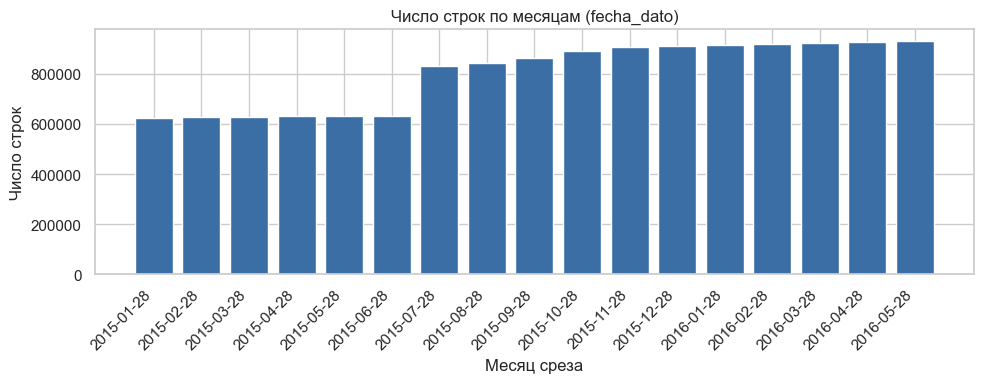

График сохранён: C:\work\yandex\source\mle-pr-final\data\processed\eda\04_rows_by_month.png
Конец обучения в конфиге: 2015-12-28 | есть в данных: True
Конец проверки в конфиге: 2016-04-28 | есть в данных: True


In [5]:
# Читаем готовую сводку, а не исходный CSV
months_df = pd.read_parquet(EDA_DIR / "03_month_counts.parquet")

fig, ax = plt.subplots()
ax.bar(months_df["fecha_dato"], months_df["n_rows"], color="#3b6ea5")
ax.set_title("Число строк по месяцам (fecha_dato)")
ax.set_xlabel("Месяц среза")
ax.set_ylabel("Число строк")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_path = EDA_DIR / "04_rows_by_month.png"
fig.savefig(fig_path, dpi=120)
plt.show()
print("График сохранён:", fig_path)

cfg_train_end = CONFIG["split"]["train_end"]
cfg_valid_end = CONFIG["split"]["valid_end"]
print("Конец обучения в конфиге:", cfg_train_end, "| есть в данных:", cfg_train_end in set(months_df["fecha_dato"]))
print("Конец проверки в конфиге:", cfg_valid_end, "| есть в данных:", cfg_valid_end in set(months_df["fecha_dato"]))

#### Выводы
- Нужно проверять качество нужно на более поздних месяцах, чем те, на которых учили модель.
- Самый последний месяц файла сам по себе не годится как объект обучения: для него нет «следующего месяца», из которого взять правильный ответ.

## 6. Сохраняем облегчённые таблицы по месяцам и считаем пересечение клиентов

Логика для использования сравнения продуктов в соседних месяцах при ограниченном объеме памяти.
Файлы с данными за месяц позволяют сравнивать только два соседних месяца, без необходимости загрузки большого датасета в память.

Одним проходом по файлу сохраняем на диск компактные таблицы на каждый месяц:
- файл только с идентификаторами клиентов;
- файл с идентификаторами и флагами 24 продуктов.

Затем по этим файлам считаем:
- сколько уникальных клиентов в каждом месяце;
- какая доля клиентов месяца A также есть в следующем месяце B.


Кусков при сохранении помесячных файлов: 5
Кусков при сохранении помесячных файлов: 10
Кусков при сохранении помесячных файлов: 15
Кусков при сохранении помесячных файлов: 20
Кусков при сохранении помесячных файлов: 25
Кусков при сохранении помесячных файлов: 30
Кусков при сохранении помесячных файлов: 35
Сохранено месяцев: 17 → C:\work\yandex\source\mle-pr-final\data\processed\eda\months_slim
Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\05_clients_per_month.parquet C:\work\yandex\source\mle-pr-final\data\processed\eda\05_month_overlap.parquet


,fecha_dato,n_clients
0,2015-01-28,625457
1,2015-02-28,627394
2,2015-03-28,629209
3,2015-04-28,630367
4,2015-05-28,631957
5,2015-06-28,632110
6,2015-07-28,829817
7,2015-08-28,843201
8,2015-09-28,865440
9,2015-10-28,892251


,fecha_dato_t,fecha_dato_t1,n_t,n_t1,n_overlap,overlap_rate_of_t
0,2015-01-28,2015-02-28,625457,627394,622926,0.995953
1,2015-02-28,2015-03-28,627394,629209,625094,0.996334
2,2015-03-28,2015-04-28,629209,630367,626698,0.996009
3,2015-04-28,2015-05-28,630367,631957,628135,0.996459
4,2015-05-28,2015-06-28,631957,632110,628603,0.994693
5,2015-06-28,2015-07-28,632110,829817,630249,0.997056
6,2015-07-28,2015-08-28,829817,843201,828361,0.998245
7,2015-08-28,2015-09-28,843201,865440,841795,0.998333
8,2015-09-28,2015-10-28,865440,892251,863690,0.997978
9,2015-10-28,2015-11-28,892251,906109,890170,0.997668


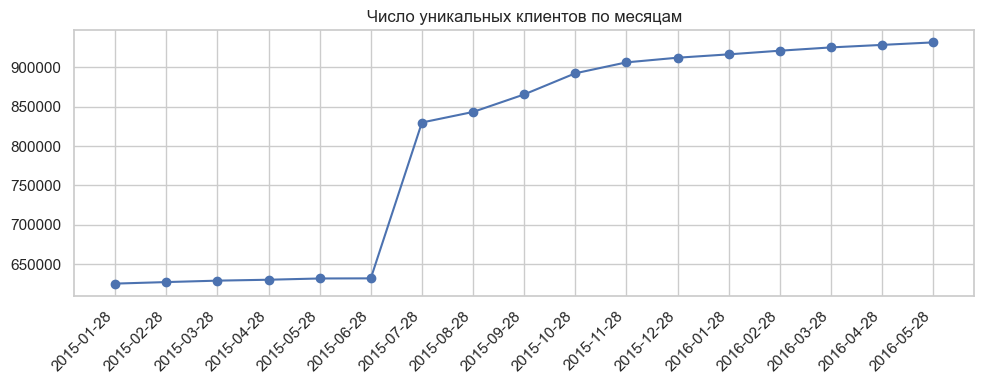

In [6]:
SLIM_DIR.mkdir(parents=True, exist_ok=True)

prod_cols_present = [c for c in PRODUCT_COLS if c in header_cols]
slim_cols = [ID_COL, DATE_COL] + prod_cols_present

# Временные «корзины» в памяти: копим куски месяца, затем периодически записываем на диск
buffers_ids: dict[str, list[pd.DataFrame]] = {}
buffers_prod: dict[str, list[pd.DataFrame]] = {}
BUF_FLUSH_ROWS = 250_000  # порог: после стольких накопленных строк месяца — запись на диск


def flush_month(date: str, force: bool = False) -> None:
    """Записывает накопленные строки одного месяца на диск.

    Если файл месяца уже существует, дописываем к нему и убираем дубликаты клиента.
    """
    id_parts = buffers_ids.get(date, [])
    prod_parts = buffers_prod.get(date, [])
    id_rows = sum(len(x) for x in id_parts)
    # Пока строк мало и принудительной записи нет — ждём, чтобы реже трогать диск
    if not id_parts or (not force and id_rows < BUF_FLUSH_ROWS):
        return

    id_path = SLIM_DIR / f"{date}_ids.parquet"
    prod_path = SLIM_DIR / f"{date}_products.parquet"
    id_new = pd.concat(id_parts, ignore_index=True)
    prod_new = pd.concat(prod_parts, ignore_index=True)
    buffers_ids[date] = []
    buffers_prod[date] = []

    if id_path.exists():
        id_new = pd.concat([pd.read_parquet(id_path), id_new], ignore_index=True)
    if prod_path.exists():
        prod_new = pd.concat([pd.read_parquet(prod_path), prod_new], ignore_index=True)

    # В одном месяце у клиента должна остаться одна строка
    id_new = id_new.drop_duplicates(subset=[ID_COL], keep="last")
    prod_new = prod_new.drop_duplicates(subset=[ID_COL], keep="last")
    id_new.to_parquet(id_path, index=False)
    prod_new.to_parquet(prod_path, index=False)
    del id_new, prod_new
    gc.collect()


# Пересобираем помесячные файлы с нуля
for p in SLIM_DIR.glob("*.parquet"):
    p.unlink()

reader = pd.read_csv(
    RAW_PATH,
    usecols=slim_cols,
    dtype={ID_COL: "int32", DATE_COL: "string", **{c: "Int8" for c in prod_cols_present}},
    chunksize=CHUNKSIZE,
)

for i, chunk in enumerate(reader):
    chunk[DATE_COL] = chunk[DATE_COL].astype("string").str.slice(0, 10)
    for d, g in chunk.groupby(DATE_COL, sort=False):
        buffers_ids.setdefault(d, []).append(g[[ID_COL]].copy())
        prod = g[[ID_COL] + prod_cols_present].copy()
        # Пустые флаги продуктов для этой задачи удобно считать как 0 (продукта нет)
        for c in prod_cols_present:
            prod[c] = pd.to_numeric(prod[c], errors="coerce").fillna(0).astype("int8")
        buffers_prod.setdefault(d, []).append(prod)
        flush_month(d, force=False)
    if (i + 1) % 5 == 0:
        print(f"Кусков при сохранении помесячных файлов: {i + 1}")
    del chunk
    gc.collect()

# Дописываем хвосты, которые не добрали порог BUF_FLUSH_ROWS
for d in list(buffers_ids.keys()):
    flush_month(d, force=True)

slim_index = sorted({p.name[:10] for p in SLIM_DIR.glob("*_ids.parquet")})
(SLIM_DIR / "index.json").write_text(json.dumps(slim_index, ensure_ascii=False, indent=2), encoding="utf-8")
print("Сохранено месяцев:", len(slim_index), "→", SLIM_DIR)

# Считаем число клиентов и пересечение соседних месяцев.
# В памяти одновременно держим идентификаторы только двух месяцев.
clients_rows = []
overlap_rows = []
prev_date = None
prev_ids: set[int] | None = None

for d in slim_index:
    cur_ids = set(pd.read_parquet(SLIM_DIR / f"{d}_ids.parquet")[ID_COL].tolist())
    clients_rows.append({"fecha_dato": d, "n_clients": len(cur_ids)})
    if prev_ids is not None and prev_date is not None:
        common = len(prev_ids & cur_ids)  # сколько клиентов есть и в прошлом, и в текущем месяце
        overlap_rows.append(
            {
                "fecha_dato_t": prev_date,
                "fecha_dato_t1": d,
                "n_t": len(prev_ids),
                "n_t1": len(cur_ids),
                "n_overlap": common,
                "overlap_rate_of_t": common / len(prev_ids) if prev_ids else np.nan,
            }
        )
        prev_ids.clear()
    prev_date, prev_ids = d, cur_ids
    gc.collect()

if prev_ids is not None:
    prev_ids.clear()

clients_df = pd.DataFrame(clients_rows)
overlap_df = pd.DataFrame(overlap_rows)
clients_path = EDA_DIR / "05_clients_per_month.parquet"
overlap_path = EDA_DIR / "05_month_overlap.parquet"
clients_df.to_parquet(clients_path, index=False)
overlap_df.to_parquet(overlap_path, index=False)
print("Сохранено:", clients_path, overlap_path)
display(clients_df)
display(overlap_df)

fig, ax = plt.subplots()
ax.plot(clients_df["fecha_dato"], clients_df["n_clients"], marker="o")
ax.set_title("Число уникальных клиентов по месяцам")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(EDA_DIR / "05_clients_by_month.png", dpi=120)
plt.show()

#### Выводы
В случае, если пересечение соседних месяцев большое, то один и тот же клиент появляется много раз во времени, нельзя перемешивать строки случайно при проверке качества: легко заглянуть в будущее.
Правильнее учить на ранних месяцах и проверять на более поздних.

## 7. Анкета клиента: распределения на аккуратной выборке

Для понимания формы распределений достаточно ограниченной, но разнообразной выборки. Полную таблицу профиля в память не загружаем; выборку сохраняем на диск, чтобы потом быстро перестроить графики.

Собираем выборку примерно на `SAMPLE_ROWS` строк так, чтобы в ней были представлены разные месяцы (не только начало файла). 
- приводим возраст, стаж и доход к числам;
- смотрим типичные диапазоны и выбросы;
- смотрим, какие значения чаще встречаются в ключевых категориальных полях (пол, сегмент, активность и т.д.).

In [7]:
months_df = pd.read_parquet(EDA_DIR / "03_month_counts.parquet")
n_months = max(len(months_df), 1)
# Сколько строк хотим взять из каждого месяца (квота), чтобы месяцы были представлены равномернее
per_month_target = max(SAMPLE_ROWS // n_months, 5_000)

profile_usecols = [c for c in [ID_COL, DATE_COL] + PROFILE_COLS if c in header_cols]
sampled_parts: list[pd.DataFrame] = []
per_month_have: dict[str, int] = {d: 0 for d in months_df["fecha_dato"]}

reader = pd.read_csv(
    RAW_PATH,
    usecols=profile_usecols,
    dtype={k: v for k, v in DTYPE_MAP.items() if k in profile_usecols},
    chunksize=CHUNKSIZE,
    low_memory=False,
)

for chunk in reader:
    chunk[DATE_COL] = chunk[DATE_COL].astype("string").str.slice(0, 10)
    # Берём строки только тех месяцев, где квота ещё не набрана
    need_mask = chunk[DATE_COL].map(lambda d: per_month_have.get(d, per_month_target) < per_month_target)
    if not need_mask.any():
        if all(v >= per_month_target for v in per_month_have.values()):
            break
        continue

    part = chunk.loc[need_mask].copy()
    # Перемешиваем кусок, чтобы не брать всегда только «начало» файла
    part = part.sample(frac=1.0, random_state=RANDOM_SEED)

    keep_idx = []
    for d, g in part.groupby(DATE_COL, sort=False):
        need = per_month_target - per_month_have.get(d, 0)
        if need <= 0:
            continue
        take = g.head(need)
        keep_idx.append(take)
        per_month_have[d] = per_month_have.get(d, 0) + len(take)
    if keep_idx:
        sampled_parts.append(pd.concat(keep_idx, ignore_index=True))

    del chunk, part
    gc.collect()
    if all(v >= per_month_target for v in per_month_have.values()):
        break

profile_sample = pd.concat(sampled_parts, ignore_index=True) if sampled_parts else pd.DataFrame()
del sampled_parts
gc.collect()

# Чистим числовые поля анкеты
for col in ("age", "antiguedad", "renta"):
    if col in profile_sample.columns:
        profile_sample[col] = to_numeric_clean(profile_sample[col])

sample_path = EDA_DIR / "06_profile_sample.parquet"
profile_sample.to_parquet(sample_path, index=False)
print("Размер выборки профиля:", profile_sample.shape, "→", sample_path)
print("Набрано строк по месяцам (минимум / максимум):", min(per_month_have.values()), max(per_month_have.values()))

display(profile_sample[[c for c in ["age", "antiguedad", "renta"] if c in profile_sample.columns]].describe())

# После очистки числа становятся пригодными для графиков.

Размер выборки профиля: (149991, 24) → C:\work\yandex\source\mle-pr-final\data\processed\eda\06_profile_sample.parquet
Набрано строк по месяцам (минимум / максимум): 8823 8823


,age,antiguedad,renta
count,149623.0,149623.0,118703.0
mean,40.42954,69.345836,133644.128102
std,17.050185,2586.086308,220167.811502
min,2.0,-999999.0,5040.39
25%,25.0,25.0,69172.425
50%,39.0,60.0,101683.74
75%,50.0,120.0,155309.895
max,116.0,254.0,22034738.76


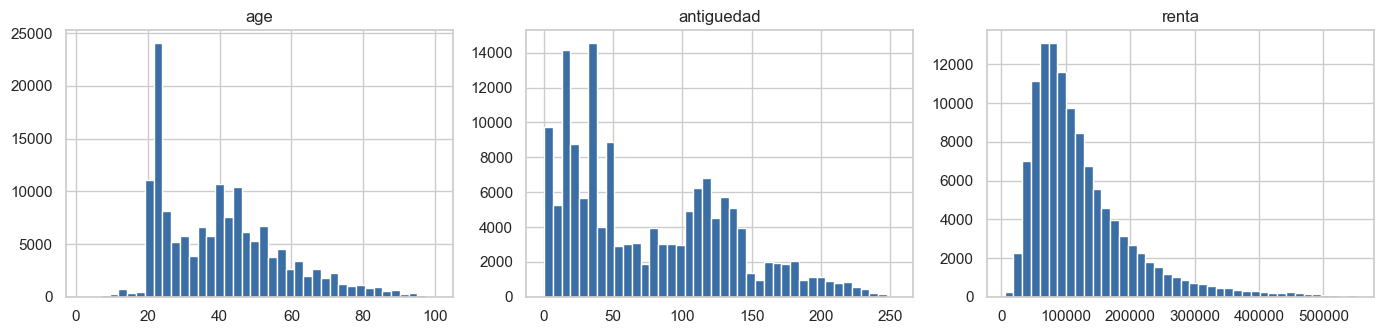

Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\06_categorical_freq.parquet


,value,rate,column
0,V,0.541052,sexo
1,H,0.456487,sexo
2,<<пусто>>,0.00246,sexo
3,02 - PARTICULARES,0.610837,segmento
4,03 - UNIVERSITARIO,0.342814,segmento
5,01 - TOP,0.038476,segmento
6,<<пусто>>,0.007874,segmento
7,I,0.541312,tiprel_1mes
8,A,0.452427,tiprel_1mes
9,<<пусто>>,0.00578,tiprel_1mes


In [8]:
profile_sample = pd.read_parquet(EDA_DIR / "06_profile_sample.parquet")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

# Для борьбы редкими огромными выбросами обрезаем хвост по 99-му процентилю
renta_q99 = (
    float(profile_sample["renta"].quantile(0.99))
    if "renta" in profile_sample.columns and profile_sample["renta"].notna().any()
    else 1.0
)
for ax, col, clip in zip(
    axes,
    ["age", "antiguedad", "renta"],
    [(0, 100), (0, 300), (0, renta_q99)],
):
    if col not in profile_sample.columns:
        ax.set_visible(False)
        continue
    s = profile_sample[col].dropna()
    s = s[(s >= clip[0]) & (s <= clip[1])]
    ax.hist(s, bins=40, color="#3b6ea5", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
fig.savefig(EDA_DIR / "06_numeric_profile_hist.png", dpi=120)
plt.show()

cat_cols = [
    c
    for c in ["sexo", "segmento", "tiprel_1mes", "ind_actividad_cliente", "canal_entrada"]
    if c in profile_sample.columns
]
cat_parts = []
for c in cat_cols:
    cat_parts.append(
        profile_sample[c]
        .astype("string")
        .fillna("<<пусто>>")
        .value_counts(normalize=True)
        .head(10)
        .rename("rate")
        .rename_axis("value")
        .reset_index()
        .assign(column=c)
    )

cat_freq_df = pd.concat(cat_parts, ignore_index=True) if cat_parts else pd.DataFrame()
cat_path = EDA_DIR / "06_categorical_freq.parquet"
cat_freq_df.to_parquet(cat_path, index=False)
print("Сохранено:", cat_path)
display(cat_freq_df.head(40))


#### Выводы

- пол, сегмент, тип отношения с банком и активность клиента — полезные характеристики;
- канал привлечения содержит очень много разных значений: нужно укрупнять редкие категории;
- у дохода часто много пропусков и длинный «хвост» больших значений — удобнее логарифм и отдельный признак «доход неизвестен»;
- некоторые поля почти не меняются (почти всегда одно значение) — от них мало пользы:

| Поле | Доминирующее значение | Доля |
|------|----------------------|-----:|
| `tipodom` | `1` | ~99.8% |
| `ind_empleado` | `N` | ~99.7% |
| `indrel` | `1` | ~99.6% |
| `indfall` | `N` | ~99.5% |
| `pais_residencia` | `ES` | ~99.2% |
| `indresi` | `S` | ~99.2% |
| `indext` | `N` | ~95% |

Отдельно (почти пустые, а не «одно значение»): `conyuemp`, `ult_fec_cli_1t` (~99.9% NA) — в признаки не берём.


## 8. Какие продукты уже есть у клиентов и какие часто идут вместе

Определение дисбаланса продуктов (массовые|редкие) и связей продуктов между собой (например, зарплатный и пенсионный счёт) может помочь понять, почему модель может ошибаться и какие продукты логично учитывать как текущий портфель клиента.

На отдельной выборке считаем:
1. долю клиентов, у которых продукт уже открыт;
2. насколько флаги разных продуктов «ходят вместе» (если часто оба равны 1 у одних и тех же людей).

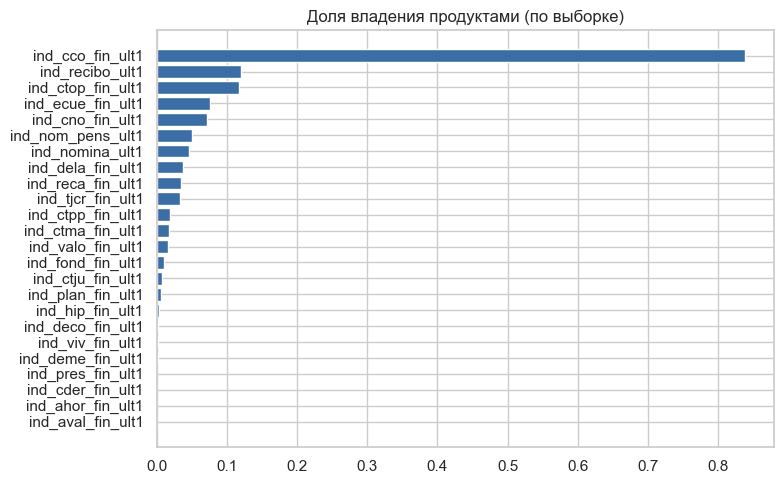

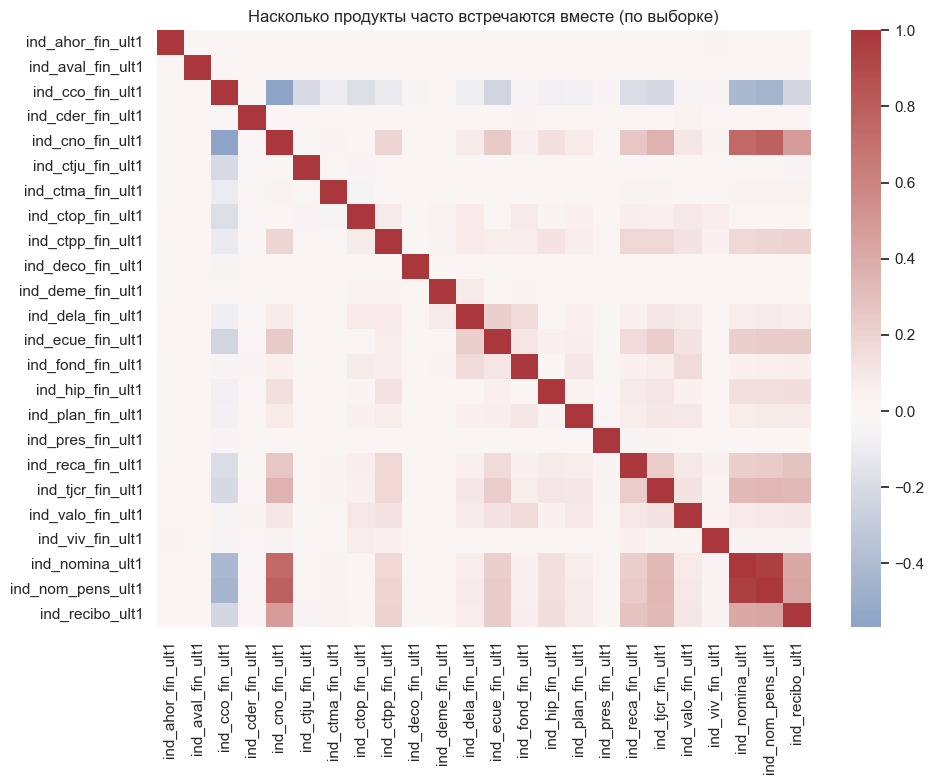

Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\07_product_ownership_sample.parquet C:\work\yandex\source\mle-pr-final\data\processed\eda\07_product_corr.parquet


,product,ownership_rate
0,ind_cco_fin_ult1,0.837367
1,ind_recibo_ult1,0.120360
2,ind_ctop_fin_ult1,0.117260
3,ind_ecue_fin_ult1,0.075847
4,ind_cno_fin_ult1,0.071453
5,ind_nom_pens_ult1,0.050387
6,ind_nomina_ult1,0.046013
7,ind_dela_fin_ult1,0.037727
8,ind_reca_fin_ult1,0.034153
9,ind_tjcr_fin_ult1,0.033300


7001

In [9]:
prod_cols_present = [c for c in PRODUCT_COLS if c in header_cols]
prod_parts: list[pd.DataFrame] = []
n_taken = 0

reader = pd.read_csv(
    RAW_PATH,
    usecols=[DATE_COL] + prod_cols_present,
    dtype={DATE_COL: "string", **{c: "Int8" for c in prod_cols_present}},
    chunksize=CHUNKSIZE,
)

for chunk in reader:
    take_n = min(len(chunk), max(SAMPLE_ROWS - n_taken, 0))
    if take_n <= 0:
        break
    part = chunk.sample(n=take_n, random_state=RANDOM_SEED)
    prod_parts.append(part[prod_cols_present].fillna(0).astype("int8"))
    n_taken += take_n
    del chunk, part
    gc.collect()

prod_sample = pd.concat(prod_parts, ignore_index=True) if prod_parts else pd.DataFrame()
del prod_parts
gc.collect()

# Среднее по столбцу 0/1 = доля клиентов, у которых продукт есть
ownership = prod_sample.mean().sort_values(ascending=False).rename("ownership_rate").reset_index()
ownership.columns = ["product", "ownership_rate"]
ownership_path = EDA_DIR / "07_product_ownership_sample.parquet"
ownership.to_parquet(ownership_path, index=False)

# Матрица совместной встречаемости продуктов (насколько флаги согласованы)
corr = prod_sample.corr()
corr_path = EDA_DIR / "07_product_corr.parquet"
corr.to_parquet(corr_path)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ownership["product"][::-1], ownership["ownership_rate"][::-1], color="#3b6ea5")
ax.set_title("Доля владения продуктами (по выборке)")
plt.tight_layout()
fig.savefig(EDA_DIR / "07_ownership_bar.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, cmap="vlag", center=0, xticklabels=True, yticklabels=True)
ax.set_title("Насколько продукты часто встречаются вместе (по выборке)")
plt.tight_layout()
fig.savefig(EDA_DIR / "07_product_corr_heatmap.png", dpi=120)
plt.show()

print("Сохранено:", ownership_path, corr_path)
display(ownership)

del prod_sample
gc.collect()

#### Выводы:
1. Продукты сильно различаются по частоте — «доля правильных ответов по всем 0/1» будет обманчиво высокой. Лучше оценивать короткий список рекомендаций (например, топ-7).
2. Связанные продукты могут открываться вместе.
3. Текущий набор продуктов клиента обязательно нужен и как вход модели, и как фильтр: уже имеющийся продукт снова предлагать не следует.

## 9. Главное для задачи: когда продукт появляется впервые (не было → стало)

Для каждой пары соседних месяцев (месяц t и следующий месяц t+1) берём клиентов, которые есть в обоих месяцах, и считаем:

> продукт считается **новым**, если в месяце t его не было (`0`), а в месяце t+1 он появился.

Такое событие модель должна научиться рекомендовать.

Для этого, сравниваем только два заранее сохранённых файлас месячными данными (для экономии памяти). Для каждой пары месяцев сохраняем распределение: у скольких клиентов было 0, 1, 2, … новых продуктов.


In [10]:
slim_index = json.loads((SLIM_DIR / "index.json").read_text(encoding="utf-8"))
_probe = pd.read_parquet(SLIM_DIR / f"{slim_index[0]}_products.parquet")
prod_cols_present = [c for c in PRODUCT_COLS if c in _probe.columns]
del _probe

transition_rows = []
product_new_rows = []
pair_dir = EDA_DIR / "transitions"
pair_dir.mkdir(exist_ok=True)

for t, t1 in zip(slim_index, slim_index[1:]):
    print(f"Сравниваем месяцы {t} → {t1}")
    df_t = pd.read_parquet(SLIM_DIR / f"{t}_products.parquet")
    df_t1 = pd.read_parquet(SLIM_DIR / f"{t1}_products.parquet")

    # Оставляем только клиентов, видимых в обоих месяцах
    merged = df_t.merge(df_t1, on=ID_COL, how="inner", suffixes=("_t", "_t1"))
    n_clients = len(merged)
    new_total = 0
    per_client_new = np.zeros(n_clients, dtype=np.int16)

    for p in prod_cols_present:
        left = merged[f"{p}_t"].to_numpy()
        right = merged[f"{p}_t1"].to_numpy()
        is_new = (left == 0) & (right == 1)  # именно появление продукта
        n_new = int(is_new.sum())
        new_total += n_new
        per_client_new += is_new.astype(np.int16)
        product_new_rows.append({"fecha_dato_t": t, "fecha_dato_t1": t1, "product": p, "n_new": n_new})

    clients_with_new = int((per_client_new > 0).sum())
    transition_rows.append(
        {
            "fecha_dato_t": t,
            "fecha_dato_t1": t1,
            "n_clients_both": n_clients,
            "n_new_product_events": new_total,
            "clients_with_ge1_new": clients_with_new,
            "share_clients_with_new": clients_with_new / n_clients if n_clients else np.nan,
            "mean_new_per_client": float(per_client_new.mean()) if n_clients else np.nan,
            # p50 / p95 / p99 — типичное и «почти максимальное» число новых продуктов у клиента
            "p50_new": float(np.median(per_client_new)) if n_clients else np.nan,
            "p95_new": float(np.quantile(per_client_new, 0.95)) if n_clients else np.nan,
            "p99_new": float(np.quantile(per_client_new, 0.99)) if n_clients else np.nan,
        }
    )

    # Сколько клиентов получили 0, 1, 2... новых продуктов в этой паре месяцев
    dist = pd.Series(per_client_new).value_counts().sort_index()
    dist.rename("n_clients").rename_axis("n_new_products").reset_index().to_parquet(
        pair_dir / f"dist_{t}_{t1}.parquet", index=False
    )

    del df_t, df_t1, merged, per_client_new
    gc.collect()

transitions_df = pd.DataFrame(transition_rows)
product_new_df = pd.DataFrame(product_new_rows)

tr_path = EDA_DIR / "08_transitions_by_month.parquet"
pn_path = EDA_DIR / "08_new_by_product_month.parquet"
transitions_df.to_parquet(tr_path, index=False)
product_new_df.to_parquet(pn_path, index=False)

print("Сохранено:", tr_path, pn_path)
display(transitions_df)
display(
    product_new_df.groupby("product", as_index=False)["n_new"]
    .sum()
    .sort_values("n_new", ascending=False)
)

Сравниваем месяцы 2015-01-28 → 2015-02-28
Сравниваем месяцы 2015-02-28 → 2015-03-28
Сравниваем месяцы 2015-03-28 → 2015-04-28
Сравниваем месяцы 2015-04-28 → 2015-05-28
Сравниваем месяцы 2015-05-28 → 2015-06-28
Сравниваем месяцы 2015-06-28 → 2015-07-28
Сравниваем месяцы 2015-07-28 → 2015-08-28
Сравниваем месяцы 2015-08-28 → 2015-09-28
Сравниваем месяцы 2015-09-28 → 2015-10-28
Сравниваем месяцы 2015-10-28 → 2015-11-28
Сравниваем месяцы 2015-11-28 → 2015-12-28
Сравниваем месяцы 2015-12-28 → 2016-01-28
Сравниваем месяцы 2016-01-28 → 2016-02-28
Сравниваем месяцы 2016-02-28 → 2016-03-28
Сравниваем месяцы 2016-03-28 → 2016-04-28
Сравниваем месяцы 2016-04-28 → 2016-05-28
Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\08_transitions_by_month.parquet C:\work\yandex\source\mle-pr-final\data\processed\eda\08_new_by_product_month.parquet


,fecha_dato_t,fecha_dato_t1,n_clients_both,n_new_product_events,clients_with_ge1_new,share_clients_with_new,mean_new_per_client,p50_new,p95_new,p99_new
0,2015-01-28,2015-02-28,622926,31372,23782,0.038178,0.050362,0.0,0.0,2.0
1,2015-02-28,2015-03-28,625094,31948,25197,0.040309,0.051109,0.0,0.0,1.0
2,2015-03-28,2015-04-28,626698,30427,25496,0.040683,0.048551,0.0,0.0,1.0
3,2015-04-28,2015-05-28,628135,26311,21203,0.033755,0.041887,0.0,0.0,1.0
4,2015-05-28,2015-06-28,628603,41745,33318,0.053003,0.066409,0.0,1.0,2.0
5,2015-06-28,2015-07-28,630249,33362,26097,0.041407,0.052935,0.0,0.0,1.0
6,2015-07-28,2015-08-28,828361,29490,24326,0.029366,0.035600,0.0,0.0,1.0
7,2015-08-28,2015-09-28,841795,35696,28479,0.033831,0.042405,0.0,0.0,1.0
8,2015-09-28,2015-10-28,863690,39803,32208,0.037291,0.046085,0.0,0.0,1.0
9,2015-10-28,2015-11-28,890170,35215,28036,0.031495,0.039560,0.0,0.0,1.0


,product,n_new
20,ind_recibo_ult1,153146
15,ind_nom_pens_ult1,84709
16,ind_nomina_ult1,73753
21,ind_tjcr_fin_ult1,69118
2,ind_cco_fin_ult1,69103
4,ind_cno_fin_ult1,37098
12,ind_ecue_fin_ult1,26361
10,ind_dela_fin_ult1,12659
19,ind_reca_fin_ult1,9234
6,ind_ctma_fin_ult1,6856


#### Выводы:
- у большинства клиентов за месяц 0 новых продуктов — положительные случаи редкие;
- в среднем новых продуктов на клиента обычно меньше 1;
- у 95% клиентов число новых продуктов небольшое (часто 1–2)

следовательно список из 7 рекомендаций продуктов с запасом покрывает реальные открытия продуктов.

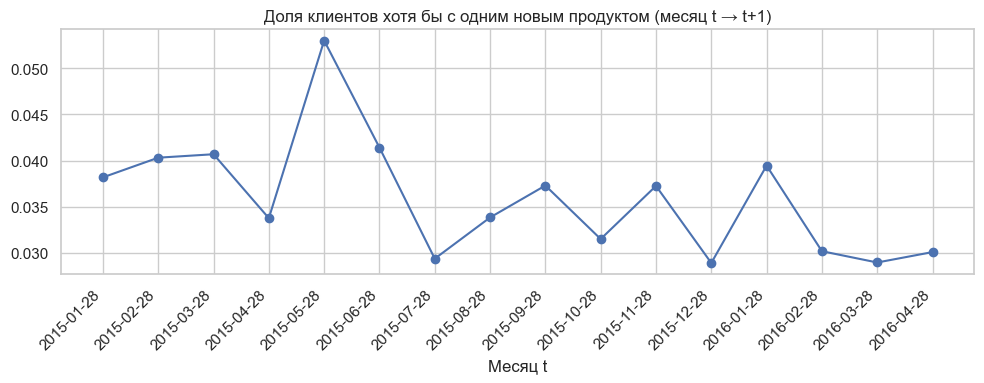

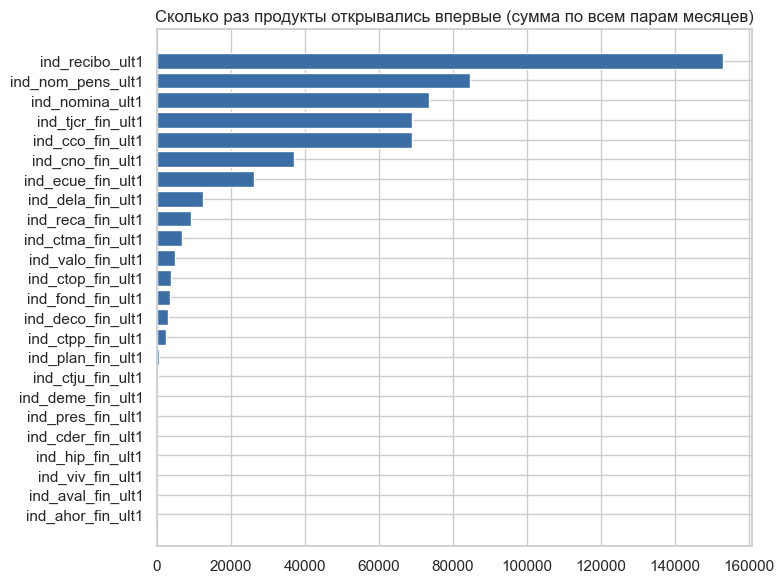

Средняя доля клиентов с новым продуктом: 0.03588322599656314
Среднее число новых продуктов на клиента: 0.045130785405737076
Медиана p95 по месяцам (почти верхняя граница числа новых продуктов): 0.0


In [11]:
transitions_df = pd.read_parquet(EDA_DIR / "08_transitions_by_month.parquet")
product_new_df = pd.read_parquet(EDA_DIR / "08_new_by_product_month.parquet")

fig, ax = plt.subplots()
ax.plot(transitions_df["fecha_dato_t"], transitions_df["share_clients_with_new"], marker="o")
ax.set_title("Доля клиентов хотя бы с одним новым продуктом (месяц t → t+1)")
ax.set_xlabel("Месяц t")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(EDA_DIR / "08_share_clients_with_new.png", dpi=120)
plt.show()

tot_new = (
    product_new_df.groupby("product", as_index=False)["n_new"].sum().sort_values("n_new", ascending=True)
)
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(tot_new["product"], tot_new["n_new"], color="#3b6ea5")
ax.set_title("Сколько раз продукты открывались впервые (сумма по всем парам месяцев)")
plt.tight_layout()
fig.savefig(EDA_DIR / "08_new_products_total.png", dpi=120)
plt.show()

print("Средняя доля клиентов с новым продуктом:", transitions_df["share_clients_with_new"].mean())
print("Среднее число новых продуктов на клиента:", transitions_df["mean_new_per_client"].mean())
print("Медиана p95 по месяцам (почти верхняя граница числа новых продуктов):", transitions_df["p95_new"].median())


## 10. План очистки данных: что заполнять, а что почти не использовать

По уже посчитанной доле пропусков составляем простой план:
- поля, которые почти всегда пустые — игнорируем;
- поля с заметной, но не катастрофической долей пропусков — заполняем и отдельно помечаем «было пусто»;
- числовые «грязные» поля — обязательно чистим;
- важные категории — заполняем аккуратно.

План сохраняем в JSON, чтобы потом перенести его в код подготовки данных (`src/data/prepare.py`).


In [12]:
na_df = pd.read_parquet(EDA_DIR / "03_na_rates.parquet")

DROP_CANDIDATE = 0.9  # если пусто в 90%+ строк — поле почти бесполезно

cleaning_plan = {
    "drop_or_ignore_if_almost_empty": na_df.loc[na_df["na_rate"] >= DROP_CANDIDATE, "column"].tolist(),
    "impute_with_missing_indicator": na_df.loc[
        (na_df["na_rate"] >= 0.05) & (na_df["na_rate"] < DROP_CANDIDATE), "column"
    ].tolist(),
    "numeric_clean": ["age", "antiguedad", "renta"],
    "categorical_fill": ["sexo", "segmento", "tiprel_1mes", "canal_entrada", "nomprov"],
    "notes": [
        "Возраст и стаж часто записаны текстом с пробелами — сначала убрать пробелы, потом перевести в число",
        "Для дохода удобны логарифм и отдельный признак «доход неизвестен»",
        "Поля ult_fec_cli_1t и conyuemp обычно почти пустые",
        "Пустые флаги продуктов на этапе подготовки удобно считать нулями (продукта нет)",
    ],
}

plan_path = EDA_DIR / "09_cleaning_plan.json"
plan_path.write_text(json.dumps(cleaning_plan, ensure_ascii=False, indent=2), encoding="utf-8")
print("Сохранено:", plan_path)
display(na_df.head(20))
cleaning_plan


Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\09_cleaning_plan.json


,column,n_na,na_rate
0,conyuemp,13645501,0.999868
1,ult_fec_cli_1t,13622516,0.998183
2,renta,2794375,0.204756
3,segmento,189368,0.013876
4,canal_entrada,186126,0.013638
5,indrel_1mes,149781,0.010975
6,tiprel_1mes,149781,0.010975
7,nomprov,93591,0.006858
8,cod_prov,93591,0.006858
9,sexo,27804,0.002037


{'drop_or_ignore_if_almost_empty': ['conyuemp', 'ult_fec_cli_1t'],
 'impute_with_missing_indicator': ['renta'],
 'numeric_clean': ['age', 'antiguedad', 'renta'],
 'categorical_fill': ['sexo',
  'segmento',
  'tiprel_1mes',
  'canal_entrada',
  'nomprov'],
 'notes': ['Возраст и стаж часто записаны текстом с пробелами — сначала убрать пробелы, потом перевести в число',
  'Для дохода удобны логарифм и отдельный признак «доход неизвестен»',
  'Поля ult_fec_cli_1t и conyuemp обычно почти пустые',
  'Пустые флаги продуктов на этапе подготовки удобно считать нулями (продукта нет)']}

## 11. Как разделить данные на обучение и проверку по времени

Сверяем список месяцев в файле с датами из конфига и предлагаем разбиение:
- ранние месяцы — обучение;
- следующие — выбор модели / настройка;
- самый поздний месяц, у которого ещё есть следующий месяц — финальная проверка.

>**Важное правило!**
Для объекта «клиент в месяце t» правильный ответ берётся из месяца t+1.  
Поэтому последний месяц файла нельзя использовать как объект обучения: для него нет следующего месяца с ответом.


In [13]:
months = pd.read_parquet(EDA_DIR / "03_month_counts.parquet")["fecha_dato"].tolist()
pairable = months[:-1]  # у этих месяцев есть следующий месяц с правильным ответом

cfg_train_end = CONFIG["split"]["train_end"]
cfg_valid_end = CONFIG["split"]["valid_end"]

suggestion = {
    "months_in_data": months,
    "pairable_fecha_dato_t": pairable,
    "config": {"train_end": cfg_train_end, "valid_end": cfg_valid_end},
    "config_train_end_ok": cfg_train_end in months,
    "config_valid_end_ok": cfg_valid_end in months,
    "recommended": {
        # Если даты конфига есть в данных — опираемся на них
        "train_fecha_dato_t": [d for d in pairable if d <= cfg_train_end]
        if cfg_train_end in months
        else pairable[: max(len(pairable) - 4, 1)],
        "valid_fecha_dato_t": [d for d in pairable if cfg_train_end < d <= cfg_valid_end]
        if cfg_train_end in months and cfg_valid_end in months
        else pairable[max(len(pairable) - 4, 1) : max(len(pairable) - 1, 1)],
        "holdout_fecha_dato_t": [pairable[-1]] if pairable else [],
        "unused_last_month_without_target": months[-1] if months else None,
    },
}

split_path = EDA_DIR / "10_split_suggestion.json"
split_path.write_text(json.dumps(suggestion, ensure_ascii=False, indent=2), encoding="utf-8")
print("Сохранено:", split_path)
suggestion

Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\10_split_suggestion.json


{'months_in_data': ['2015-01-28',
  '2015-02-28',
  '2015-03-28',
  '2015-04-28',
  '2015-05-28',
  '2015-06-28',
  '2015-07-28',
  '2015-08-28',
  '2015-09-28',
  '2015-10-28',
  '2015-11-28',
  '2015-12-28',
  '2016-01-28',
  '2016-02-28',
  '2016-03-28',
  '2016-04-28',
  '2016-05-28'],
 'pairable_fecha_dato_t': ['2015-01-28',
  '2015-02-28',
  '2015-03-28',
  '2015-04-28',
  '2015-05-28',
  '2015-06-28',
  '2015-07-28',
  '2015-08-28',
  '2015-09-28',
  '2015-10-28',
  '2015-11-28',
  '2015-12-28',
  '2016-01-28',
  '2016-02-28',
  '2016-03-28',
  '2016-04-28'],
 'config': {'train_end': '2015-12-28', 'valid_end': '2016-04-28'},
 'config_train_end_ok': True,
 'config_valid_end_ok': True,
 'recommended': {'train_fecha_dato_t': ['2015-01-28',
   '2015-02-28',
   '2015-03-28',
   '2015-04-28',
   '2015-05-28',
   '2015-06-28',
   '2015-07-28',
   '2015-08-28',
   '2015-09-28',
   '2015-10-28',
   '2015-11-28',
   '2015-12-28'],
  'valid_fecha_dato_t': ['2016-01-28',
   '2016-02-28',
  

## 12. Краткая сводка исследования

Собираем короткое резюме из уже сохранённых таблиц: сколько месяцев и строк, как часто бывают новые продукты, какие продукты самые частые и самые редкие. 

In [14]:
months_df = pd.read_parquet(EDA_DIR / "03_month_counts.parquet")
transitions_df = pd.read_parquet(EDA_DIR / "08_transitions_by_month.parquet")
ownership = pd.read_parquet(EDA_DIR / "03_product_ownership.parquet").sort_values(
    "ownership_rate", ascending=False
)

summary = {
    "n_months": int(len(months_df)),
    "date_min": months_df["fecha_dato"].min(),
    "date_max": months_df["fecha_dato"].max(),
    "n_rows_total": int(months_df["n_rows"].sum()),
    "avg_share_clients_with_new": float(transitions_df["share_clients_with_new"].mean()),
    "avg_mean_new_per_client": float(transitions_df["mean_new_per_client"].mean()),
    "top5_owned_products": ownership.head(5)[["product", "ownership_rate"]].to_dict(orient="records"),
    "bottom5_owned_products": ownership.tail(5)[["product", "ownership_rate"]].to_dict(orient="records"),
    "artifact_dir": str(EDA_DIR),
}
summary_path = EDA_DIR / "11_eda_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Сохранено:", summary_path)
summary


Сохранено: C:\work\yandex\source\mle-pr-final\data\processed\eda\11_eda_summary.json


{'n_months': 17,
 'date_min': '2015-01-28',
 'date_max': '2016-05-28',
 'n_rows_total': 13647309,
 'avg_share_clients_with_new': 0.03588322599656314,
 'avg_mean_new_per_client': 0.045130785405737076,
 'top5_owned_products': [{'product': 'ind_cco_fin_ult1',
   'ownership_rate': 0.6554836561552171},
  {'product': 'ind_ctop_fin_ult1', 'ownership_rate': 0.12900829020578342},
  {'product': 'ind_recibo_ult1', 'ownership_rate': 0.127916206777468},
  {'product': 'ind_ecue_fin_ult1', 'ownership_rate': 0.0827435650500769},
  {'product': 'ind_cno_fin_ult1', 'ownership_rate': 0.08086722444695874}],
 'bottom5_owned_products': [{'product': 'ind_deco_fin_ult1',
   'ownership_rate': 0.0017787389440658229},
  {'product': 'ind_deme_fin_ult1', 'ownership_rate': 0.0016609867923412594},
  {'product': 'ind_cder_fin_ult1', 'ownership_rate': 0.0003939238131121674},
  {'product': 'ind_ahor_fin_ult1', 'ownership_rate': 0.00010229122825606132},
  {'product': 'ind_aval_fin_ult1', 'ownership_rate': 2.3154747943349

### Отчёт: что показали данные и как дальше ставим задачу

Кратко собираем выводы EDA — без повторного чтения большого CSV. Это опора для `prepare`, признаков и экспериментов.

1. **Как устроены данные.**  
   Файл — помесячные срезы клиентов (`fecha_dato`). Для обучения берём клиента в месяце **t** (профиль + портфель), а правильный ответ смотрим в месяце **t+1**. Последний месяц файла (`2016-05-28`) как объект обучения не годится: для него нет следующего месяца с ответом.

2. **Что именно предсказываем.**  
   Нас интересует только **новое** открытие: продукта не было в t (`0`) и он появился в t+1 (`1`). Уже имеющиеся продукты снова предлагать не нужно. Удержание / «останется ли продукт» в эту задачу не входит.

3. **Как измерять качество.**  
   У большинства клиентов за месяц **0** новых продуктов, поэтому обычная «доля правильных ответов» почти всегда выглядит высокой и мало говорит о пользе. Лучше смотреть короткий список из **7** рекомендаций: попал ли нужный продукт в топ‑7 и насколько высоко он стоит (MAP@7, Precision@7, Recall@7).

4. **Как делить на обучение и проверку.**  
   Один и тот же клиент часто встречается в соседних месяцах. Если перемешать строки случайно, легко заглянуть в будущее. Правильнее учить на **ранних** месяцах и проверять на **более поздних**.  
   По данным и конфигу: train — `2015-01`…`2015-12`, valid — `2016-01`…`2016-04`. Даты из `configs/train.yaml` в файле есть, сдвигать их не пришлось.

5. **Какие поля полезны.**  
   Хорошие кандидаты: пол, сегмент, тип отношения с банком, активность, регион, доход (с осторожной обработкой), текущий портфель.  
   `canal_entrada` — много редких значений → редкие категории лучше укрупнять.  
   Почти константные или почти пустые поля (`tipodom`, `ind_empleado`, `conyuemp`, `ult_fec_cli_1t` и т.п.) в признаки почти не берём.

6. **Что почистить перед моделью.**  
   `age`, `antiguedad`, `renta` часто приходят текстом — сначала в числа. У `renta` много пропусков и длинный хвост → логарифм и признак «доход неизвестен». Пустые флаги продуктов удобно считать нулями (продукта нет). План очистки лежит в `data/processed/eda/09_cleaning_plan.json`.

7. **Где лежат результаты.**  
   Сводки, графики и промежуточные таблицы сохранены в `data/processed/eda/`. Их можно переиспользовать, не читая весь исходный CSV заново.

**Что делать дальше:** перенести очистку и сбор пар месяцев (t → t+1) в `src/data/prepare.py`, затем строить признаки и проводить эксперименты в `02_experiments.ipynb` с записью результатов в MLflow.


## 13. Логирование результатов EDA в MLflow

**Что делаем**

Сохраняем выводы и компактные артефакты исследования в эксперимент MLflow (как на этапе EDA в спринте 2): отчёт, графики, сводные таблицы, копия ноутбука.

**Перед запуском этой ячейки** поднимите Tracking Server в Docker:

```bash
docker compose --profile mlflow up -d mlflow
# UI: http://127.0.0.1:5000
```

Затем выполните ячейку ниже — или из терминала: `python scripts/log_eda_mlflow.py`.

Тяжёлые помесячные slim-файлы в артефакты не кладём — в run попадают сводки, графики и выводы.


In [15]:
import sys

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.eda_logging import log_eda_to_mlflow

run_id = log_eda_to_mlflow()
print("run_id:", run_id)

# Итог:
# - experiment: bank-product-recommender (configs/train.yaml)
# - run: bank-rec-eda-001
# - артефакты: eda/, eda/plots/, eda/tables/ в artifact store (S3)


EDA залогирован в MLflow
  tracking   : http://127.0.0.1:5000
  experiment : bank-product-recommender
  run        : bank-rec-eda-001 (b668a20a7b574a2a9c0d79af5f5fb638)
  UI         : http://127.0.0.1:5000/#/experiments/1
🏃 View run bank-rec-eda-001 at: http://127.0.0.1:5000/#/experiments/1/runs/b668a20a7b574a2a9c0d79af5f5fb638
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1
run_id: b668a20a7b574a2a9c0d79af5f5fb638
